In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import numpy as np

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/flights_clean.csv")
df.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,distance,hour,minute,time_hour,name,flight_date,day_of_week,route,cancelled,on_time
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.,2013-01-01,Tuesday,EWR-IAH,0,0.0
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.,2013-01-01,Tuesday,LGA-IAH,0,0.0
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.,2013-01-01,Tuesday,JFK-MIA,0,0.0
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,1576,5,45,2013-01-01 05:00:00,JetBlue Airways,2013-01-01,Tuesday,JFK-BQN,0,1.0
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.,2013-01-01,Tuesday,LGA-ATL,0,1.0


### 1. Top Airlines

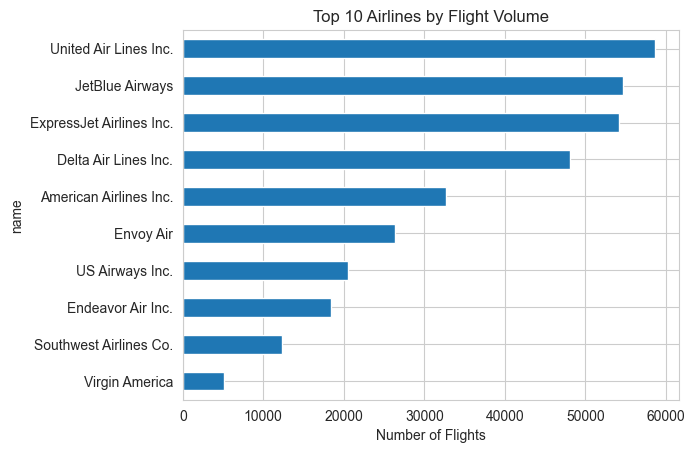

In [2]:
top_airlines = df['name'].value_counts().head(10)

plt.figure()
top_airlines.sort_values().plot(kind='barh')
plt.title("Top 10 Airlines by Flight Volume")
plt.xlabel("Number of Flights")
plt.show()

### 2. Top Routes

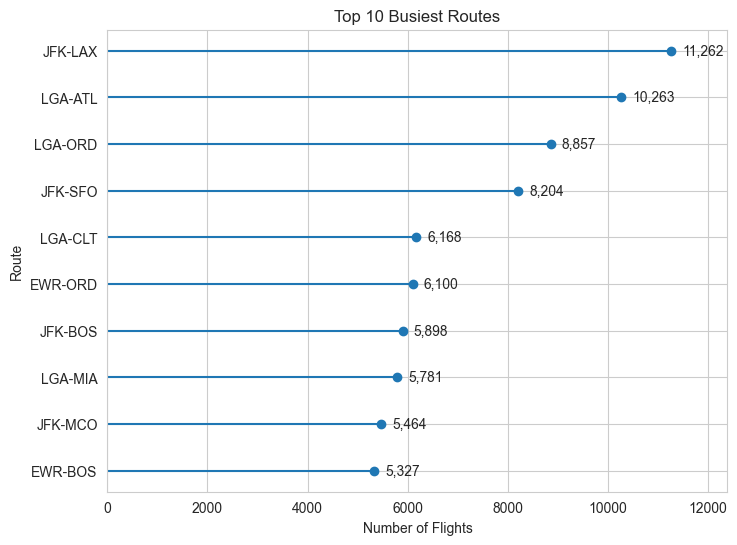

In [3]:
top_routes = df['route'].value_counts().head(10).sort_values()

plt.figure(figsize=(8,6))

plt.hlines(y=top_routes.index, xmin=0, xmax=top_routes.values)
plt.plot(top_routes.values, top_routes.index, "o")

# Dynamic spacing based on max value
offset = top_routes.max() * 0.02  

for i, value in enumerate(top_routes.values):
    plt.text(value + offset, i, f"{value:,}", 
             va='center', ha='left')

plt.xlim(0, top_routes.max() * 1.1)

plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

### 3. Number of Flights (Monthly Trend)

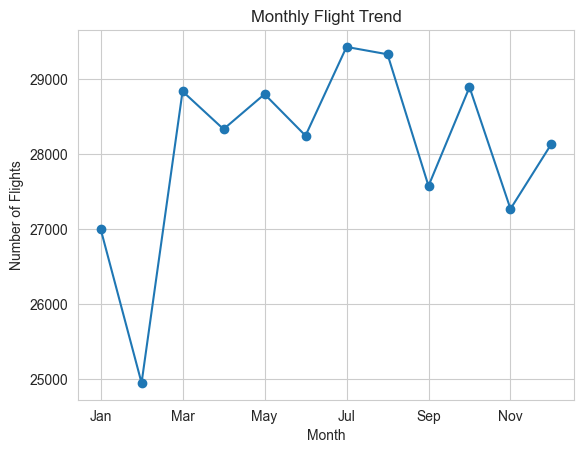

In [4]:
monthly_counts = df.groupby('month').size()

# Convert month numbers to month names
monthly_counts.index = pd.to_datetime(
    monthly_counts.index, format='%m'
).strftime('%b')

plt.figure()
monthly_counts.plot(marker='o')

plt.title("Monthly Flight Trend")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

### 4. Flights by Day of Week — Ordered Bar
##### Flight operations are evenly distributed throughout the week, with no significant weekday dominance.

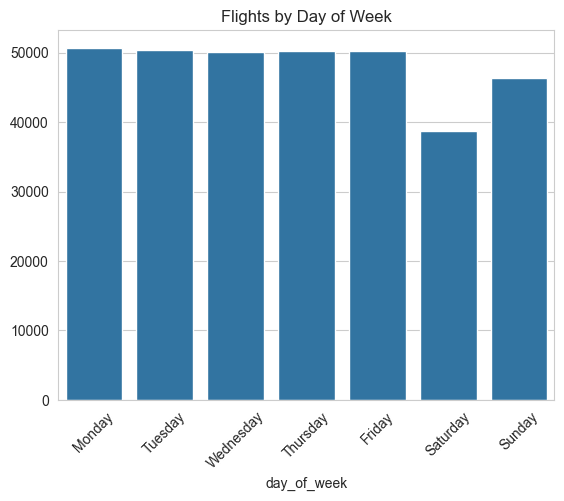

In [5]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

plt.figure()
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.xticks(rotation=45)
plt.title("Flights by Day of Week")
plt.show()

### 5. Flight Distribution by Hour — KDE Plot

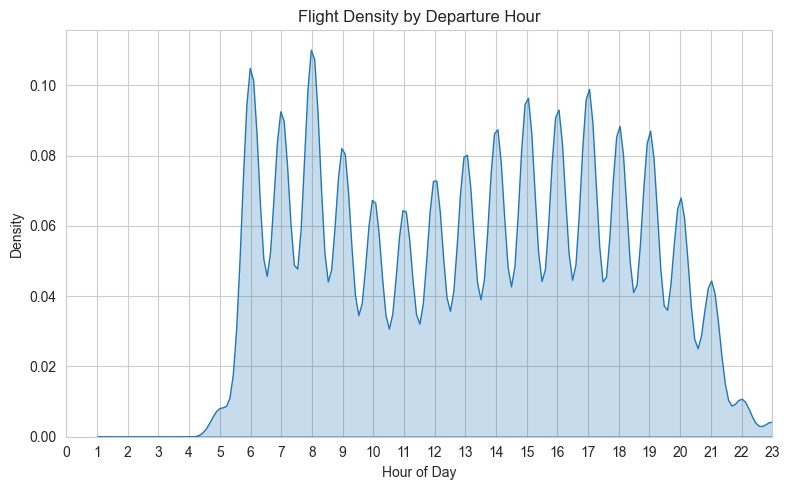

In [6]:

# Ensure hour column is numeric
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

# Drop missing values if any
df = df.dropna(subset=['hour'])

# Keep only valid 24-hour range
df = df[(df['hour'] >= 0) & (df['hour'] <= 23)]

# Plot KDE properly clipped
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='hour',
    fill=True,
    bw_adjust=0.8,      # Controls smoothness
    cut=0,              # Prevents extending beyond data range
    clip=(0, 23)        # Hard limits for x-axis smoothing
)

plt.title("Flight Density by Departure Hour")
plt.xlabel("Hour of Day")
plt.xlim(0, 23)
plt.xticks(np.arange(0, 24, 1))
plt.tight_layout()
plt.show()

### 6. Flight Distance Distribution — Histogram

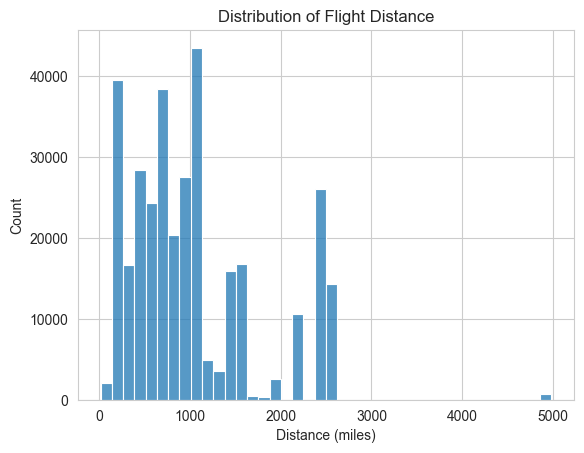

In [7]:
plt.figure()
sns.histplot(df['distance'], bins=40)
plt.title("Distribution of Flight Distance")
plt.xlabel("Distance (miles)")
plt.show()

### 7. Departure vs Arrival Delay — Scatter

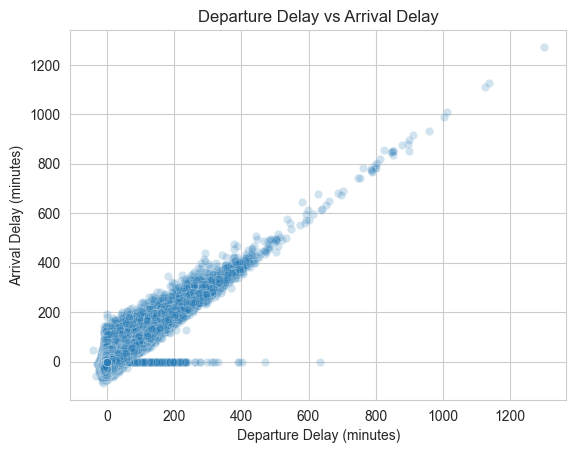

In [8]:
plt.figure()
sns.scatterplot(
    x='dep_delay',
    y='arr_delay',
    data=df,
    alpha=0.2
)
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

### 8. Average Arrival Delay by Airline — Horizontal Bar

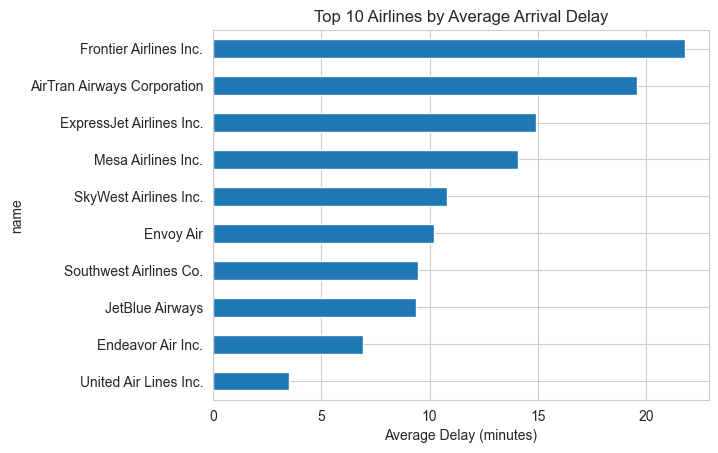

In [9]:
avg_delay_airline = (
    df.groupby('name')['arr_delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
avg_delay_airline.sort_values().plot(kind='barh')
plt.title("Top 10 Airlines by Average Arrival Delay")
plt.xlabel("Average Delay (minutes)")
plt.show()

### 9. Average Delay by Hour — Line Plot

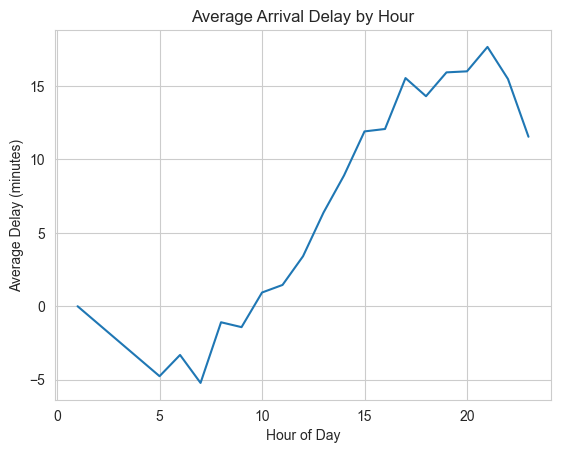

In [10]:
hour_delay = df.groupby('hour')['arr_delay'].mean()

plt.figure()
hour_delay.plot()
plt.title("Average Arrival Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")
plt.show()

### 10. Airport vs Hour Delay — Heatmap

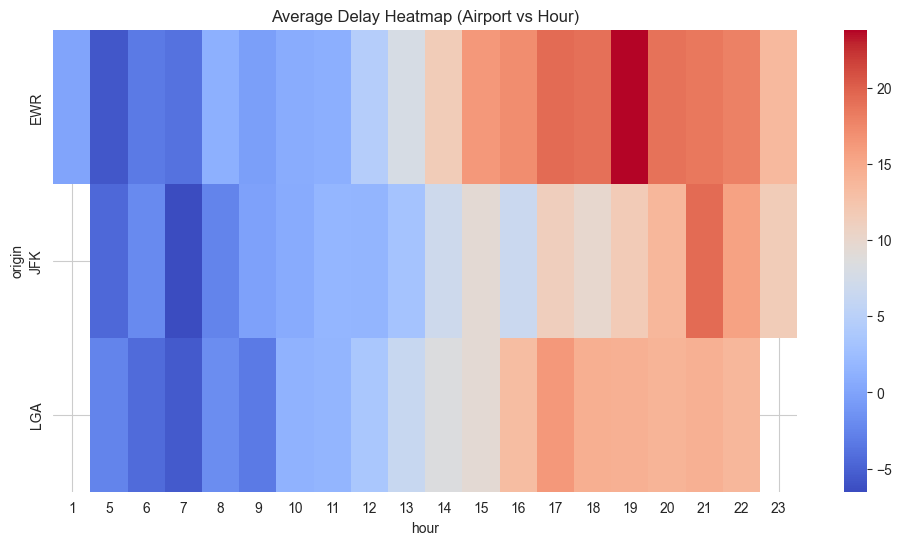

In [11]:
pivot_table = df.pivot_table(
    values='arr_delay',
    index='origin',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("Average Delay Heatmap (Airport vs Hour)")
plt.show()

In [12]:
print("AIRFLY INSIGHTS SUMMARY\n")

# Busiest Month
month_counts = df['month'].value_counts()
busiest_month = pd.to_datetime(str(month_counts.idxmax()), format='%m').strftime('%B')
print("Busiest Month:", busiest_month, f"({month_counts.max():,} flights)")

# Peak Departure Hour
hour_counts = df['hour'].value_counts()
print("Peak Departure Hour:", hour_counts.idxmax(), 
      f"({hour_counts.max():,} flights)")

# Delay Correlation
print("Departure–Arrival Delay Correlation:",
      round(df['dep_delay'].corr(df['arr_delay']), 2))

# Airline with Highest Average Delay
airline_delay = df.groupby('name')['dep_delay'].mean()
print("Airline with Highest Average Delay:",
      airline_delay.idxmax(),
      f"({airline_delay.max():.2f} mins)")

# Most Delay-Prone Hour
hour_delay = df.groupby('hour')['dep_delay'].mean()
print("Most Delay-Prone Hour:",
      hour_delay.idxmax(),
      f"({hour_delay.max():.2f} mins avg delay)")

# Airport with Highest Average Delay
airport_delay = df.groupby('origin')['dep_delay'].mean()
print("Airport with Highest Average Delay:",
      airport_delay.idxmax(),
      f"({airport_delay.max():.2f} mins avg delay)")

AIRFLY INSIGHTS SUMMARY

Busiest Month: July (29,425 flights)
Peak Departure Hour: 8 (27,242 flights)
Departure–Arrival Delay Correlation: 0.91
Airline with Highest Average Delay: Frontier Airlines Inc. (20.13 mins)
Most Delay-Prone Hour: 19 (23.79 mins avg delay)
Airport with Highest Average Delay: EWR (14.70 mins avg delay)


In [13]:
print(df.columns)

Index(['id', 'year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour', 'name', 'flight_date', 'day_of_week', 'route', 'cancelled',
       'on_time'],
      dtype='object')


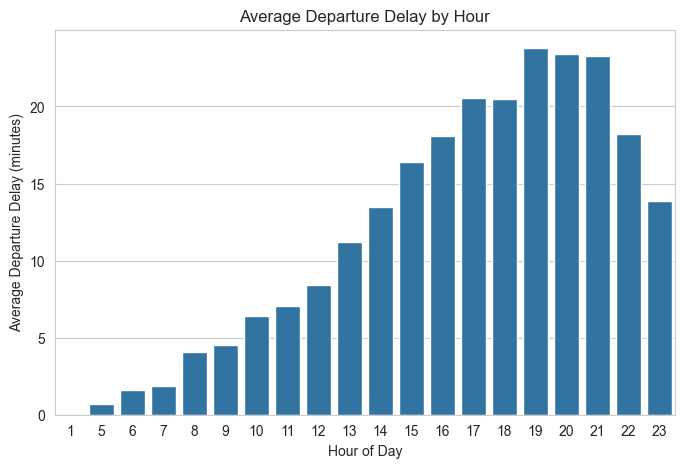

In [14]:
hour_delay = (
    df.groupby('hour')['dep_delay']
    .mean()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=hour_delay.index,
    y=hour_delay.values
)

plt.title("Average Departure Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Departure Delay (minutes)")

plt.show()

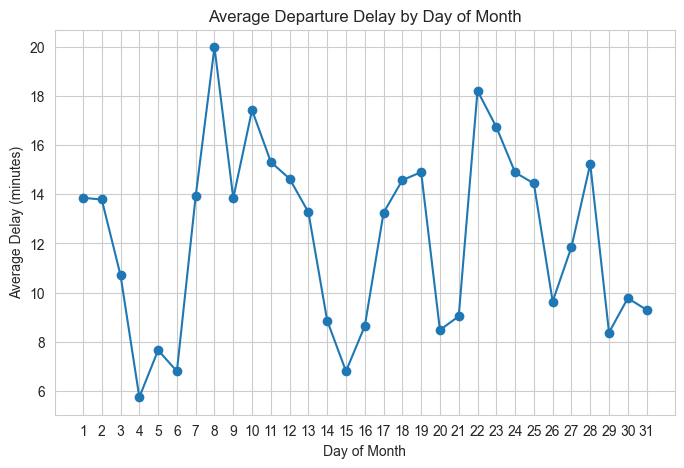

In [15]:
day_delay = (
    df.groupby('day')['dep_delay']
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(
    day_delay.index,
    day_delay.values,
    marker='o'
)

plt.title("Average Departure Delay by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Average Delay (minutes)")

plt.xticks(range(1, 32))
plt.show()

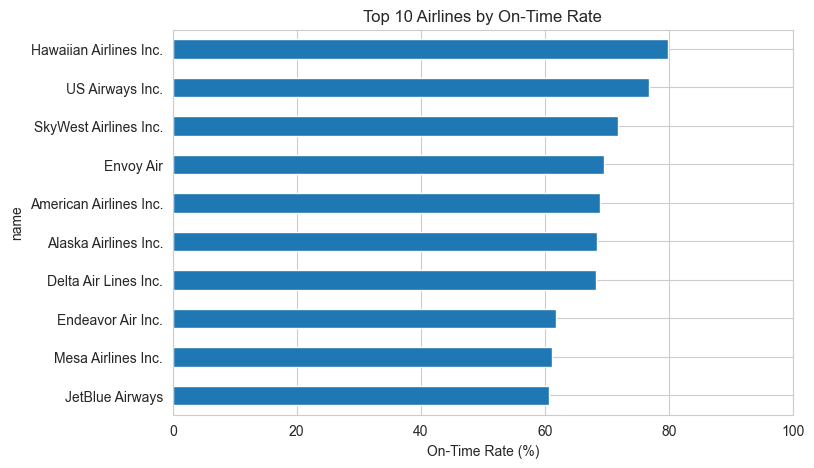

In [16]:
df['on_time'] = df['dep_delay'] <= 0

on_time_rate = (
    df.groupby('name')['on_time']
    .mean() * 100
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

on_time_rate.sort_values().plot(kind='barh')

plt.title("Top 10 Airlines by On-Time Rate")
plt.xlabel("On-Time Rate (%)")

plt.xlim(0, 100)
plt.xticks(range(0, 101, 20))   # 0,20,40,60,80,100

plt.show()